## STEP 1 — Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
print("Libraries Imported Successfully")

Libraries Imported Successfully


## STEP 2 — Load Dataset

In [3]:
df = pd.read_csv("D:/Thiranex/dataset/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## STEP 3 — Understand Dataset

In [4]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

Shape of Dataset:
(8807, 12)

Columns:
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None


## STEP 4 - Check Missing Values

In [5]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

## STEP 5 — Handle Missing Values

In [7]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['date_added'] = df['date_added'].fillna('Not Available')
print("Missing Values Handled Successfully")

Missing Values Handled Successfully


## STEP 6 — Remove Duplicates

In [8]:
print("Before Removing Duplicates:", df.shape)
df.drop_duplicates(inplace=True)
print("After Removing Duplicates:", df.shape)

Before Removing Duplicates: (8807, 12)
After Removing Duplicates: (8807, 12)


## STEP 7 — Convert Date Format

In [9]:
df['date_added'] = pd.to_datetime(
    df['date_added'],
    errors='coerce'
)
df['year_added'] = df['date_added'].dt.year
print("Date Column Converted")

Date Column Converted


## STEP 8 — Check Outliers

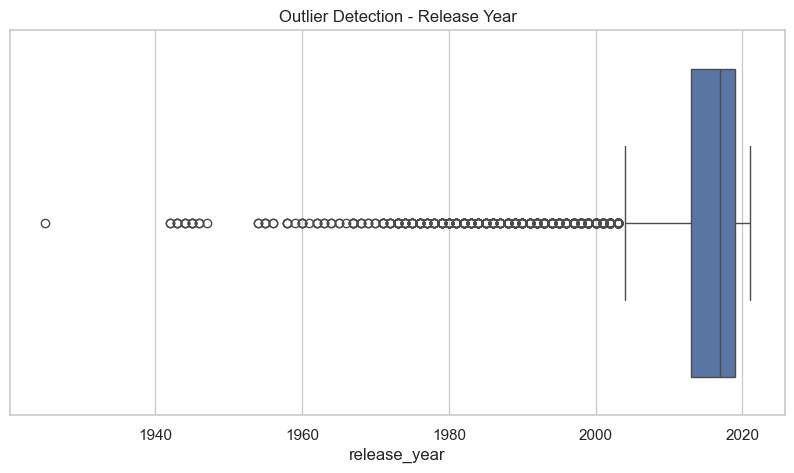

In [10]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['release_year'])
plt.title("Outlier Detection - Release Year")
plt.show()

## STEP 9 — Visualization 1
## Movies vs TV Shows

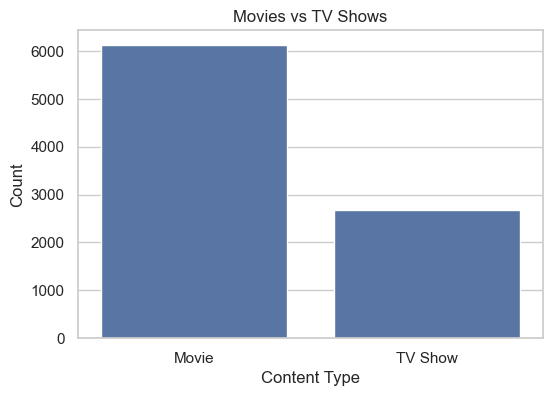

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

## STEP 10 — Visualization 2
## Top 10 Countries 

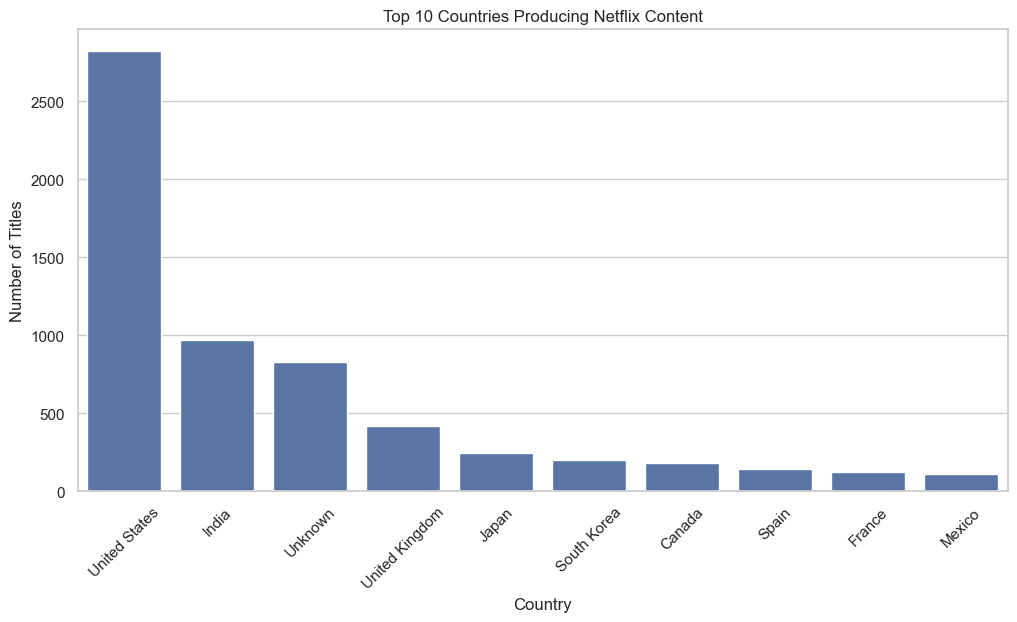

In [12]:
top_countries = df['country'].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(
    x=top_countries.index,
    y=top_countries.values
)
plt.xticks(rotation=45)
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.show()

## STEP 11 — Visualization 3
## Content Release Trend 

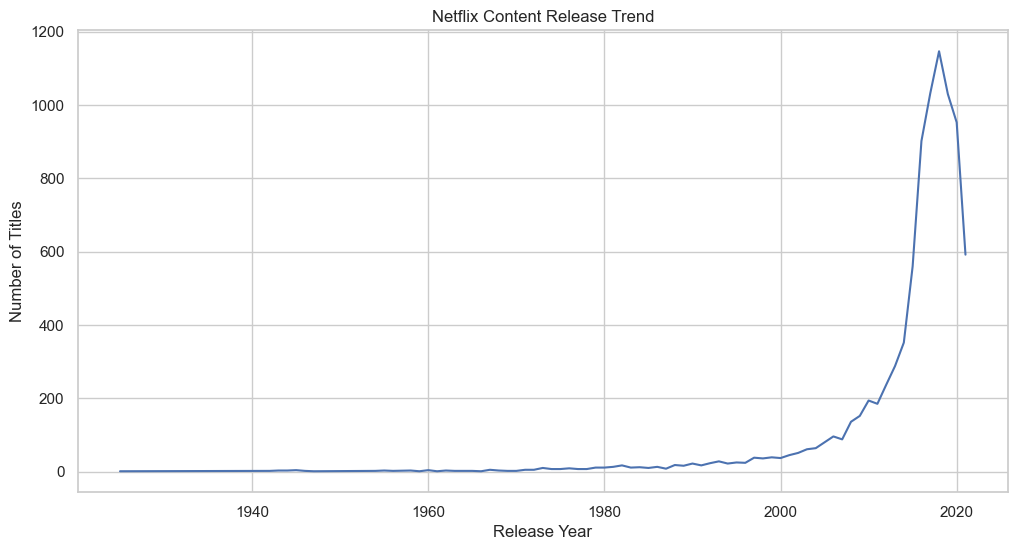

In [13]:
plt.figure(figsize=(12,6))
df['release_year'].value_counts().sort_index().plot()
plt.title("Netflix Content Release Trend")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

## STEP 12 — Visualization 4
## Ratings Distribution

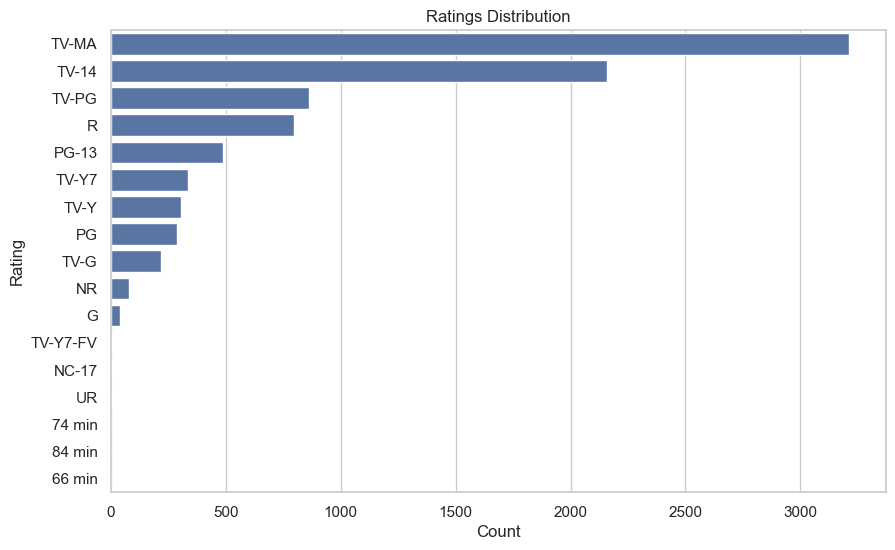

In [14]:
plt.figure(figsize=(10,6))
sns.countplot(
    y='rating',
    data=df,
    order=df['rating'].value_counts().index
)
plt.title("Ratings Distribution")
plt.xlabel("Count")
plt.ylabel("Rating")
plt.show()

## STEP 12 — Create Dashboard

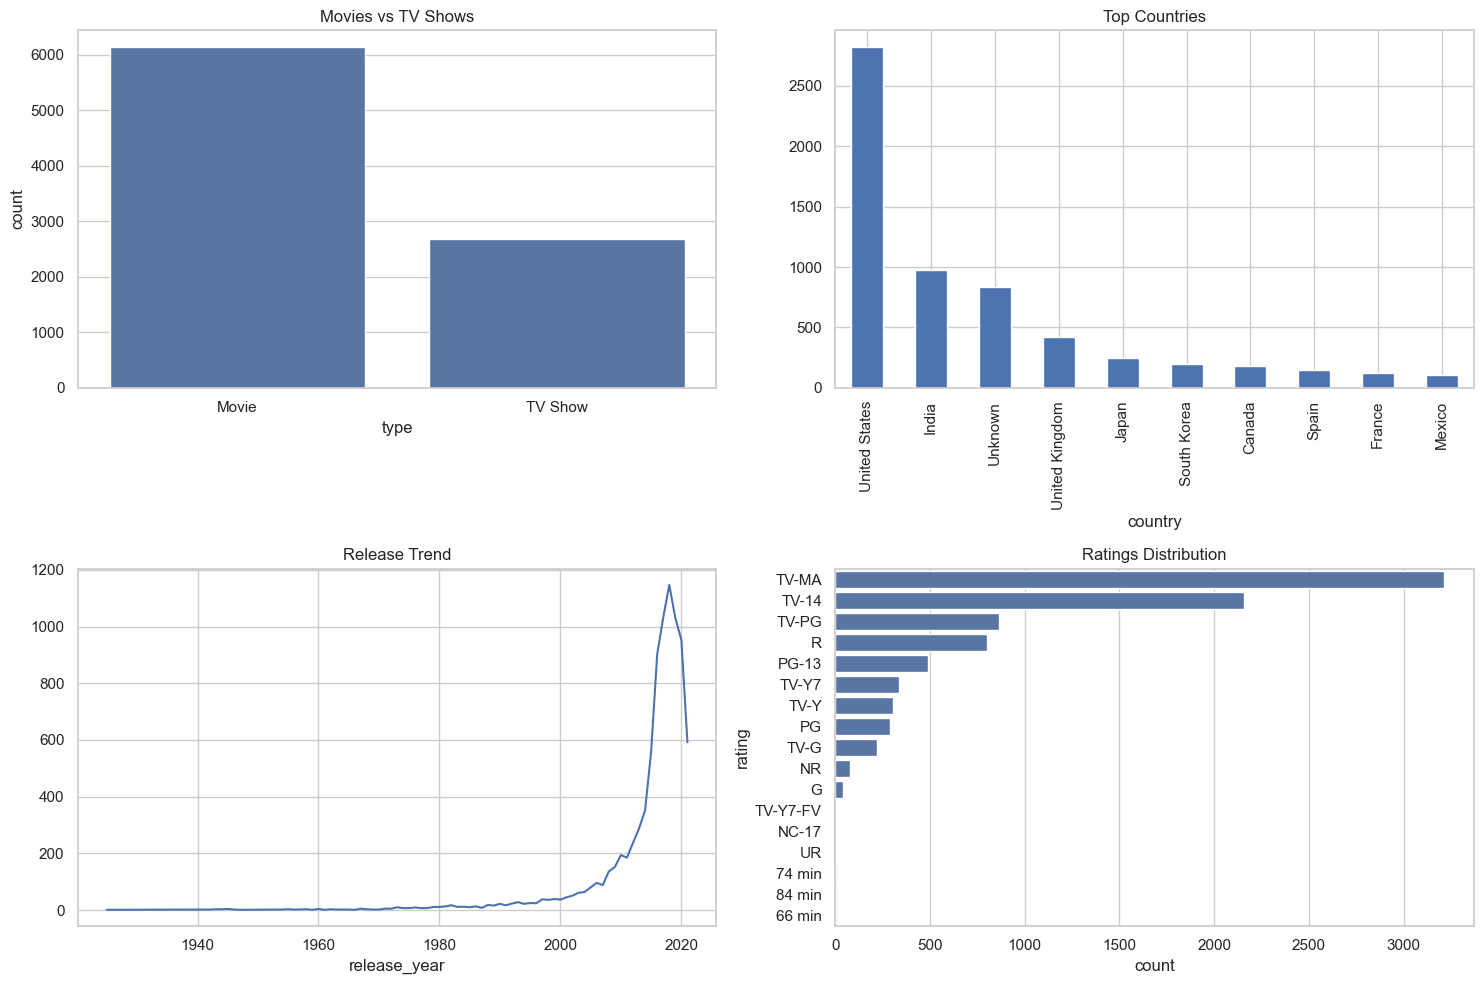

In [15]:
fig, axes = plt.subplots(2,2, figsize=(15,10))

# Plot 1
sns.countplot(x='type', data=df, ax=axes[0,0])
axes[0,0].set_title("Movies vs TV Shows")

# Plot 2
top_countries.plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title("Top Countries")

# Plot 3
df['release_year'].value_counts().sort_index().plot(ax=axes[1,0])
axes[1,0].set_title("Release Trend")

# Plot 4
sns.countplot(
    y='rating',
    data=df,
    order=df['rating'].value_counts().index,
    ax=axes[1,1]
)
axes[1,1].set_title("Ratings Distribution")
plt.tight_layout()
plt.show()

##  Key Insights

1. Movies are more common than TV Shows on Netflix.

2. The United States contributes the highest amount of Netflix content.

3. Netflix content production rapidly increased after 2015.

4. TV-MA is the most common content rating.

5. Missing values and duplicates were successfully handled during preprocessing.

## STEP 13 — Save Cleaned Dataset

In [16]:
df.to_csv(
    "cleaned_data/cleaned_netflix_dataset.csv",
    index=False
)
print("Cleaned Dataset Saved Successfully")

OSError: Cannot save file into a non-existent directory: 'cleaned_data'